In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', '{:.1f}'.format)

In [85]:
# Dados usados aonde a correção era toda feita por humanos
df_marco = pd.read_csv('correcoes_marco.csv') # 10/03/2025 a 24/03/2025
df_outubro = pd.read_csv('correcoes_outubro.csv') # 13/10/2025 a 17/10/2025
df_correcao = pd.concat([df_marco, df_outubro], ignore_index=True)
df_correcao.to_csv('correcoes.csv')
print('Tamanho dos dados de correção:',len(df_correcao))

# Filtros
df_correcao = df_correcao[
    (df_correcao['calibragem'] == False) &
    (df_correcao['reescrita'] == False) &
    (df_correcao['nomModeloCorrecaoGrupo'] == 'RED1000')
]
print('Tamanho dos dados de correção após filtros:',len(df_correcao))
print('')
print('Estatísticas Descritivas')
print('')
print(df_correcao['tempoCorrecao'].describe())

Tamanho dos dados de correção: 36377
Tamanho dos dados de correção após filtros: 34991

Estatísticas Descritivas

count     34991.0
mean       1048.2
std       18990.7
min           0.0
25%         222.0
50%         385.0
75%         687.0
max     2051381.0
Name: tempoCorrecao, dtype: float64


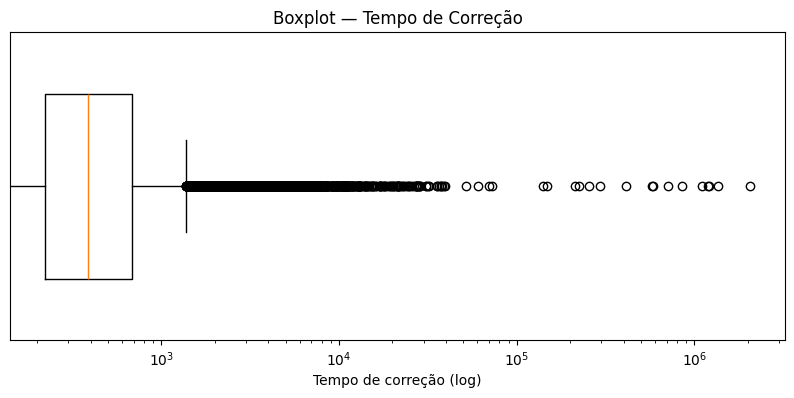

In [86]:
# Boxplot dos Tempos de Correção para analisar a dispersão dos dados e identificar outliers
plt.figure(figsize=(10, 4))
plt.boxplot(
    df_correcao["tempoCorrecao"],
    vert=False,
    widths=0.6
)

# Utilizar transformação logarítmica nos dados para melhor visualização do boxplot (diminui a escala da dispersão)
plt.xscale("log")
plt.yticks([])
plt.title("Boxplot — Tempo de Correção")
plt.xlabel("Tempo de correção (log)")
plt.show()

In [87]:
# Método para estabelecer limites inferior e superior, e posteriormente excluir outliers fora desse intervalo
q1 = df_correcao["tempoCorrecao"].quantile(0.25)
q3 = df_correcao["tempoCorrecao"].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

# Se o limite inferior for menor do que 0, alterá-lo para 0, pois não existe tempo negativo, então qualquer dado
# negativo é excluído, pois trata-se de erro de medição
if lim_inf < 0:
    lim_inf = 0

lim_inf, lim_sup

(0, np.float64(1384.5))

<Axes: >

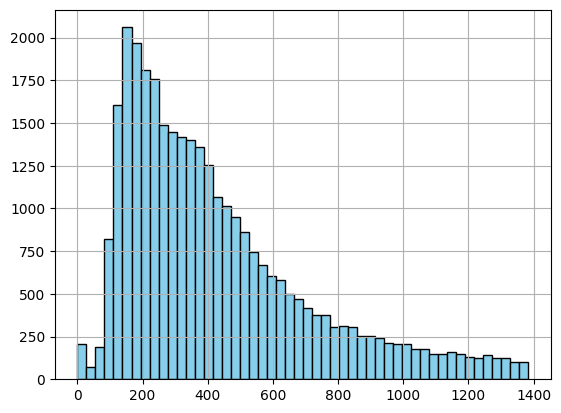

In [88]:
# Limpar outliers dos dados
df_correcao_limpo = df_correcao[
    (df_correcao["tempoCorrecao"] >= lim_inf) &
    (df_correcao["tempoCorrecao"] <= lim_sup)
]

# Armazenar outliers
df_correcao_outliers = df_correcao.loc[
    ~df_correcao.index.isin(df_correcao_limpo.index)
]

# Visualizar distribuição dos dados
df_correcao_limpo['tempoCorrecao'].hist(bins=50, color='skyblue', edgecolor='black')

In [89]:
# Meses aonde ao menos uma parte da correção é feita de forma automatizada, e portanto 
# a parte humana é de revisão, não correção
df_revisao = pd.read_csv('correcoes_novembro.csv') # 01/11/2025 a 30/11/2025
df_revisao.to_csv('revisoes.csv')
print('Tamanho dos dados de revisão:',len(df_revisao))

df_revisao = df_revisao[
    (df_revisao['calibragem'] == False) &
    (df_revisao['reescrita'] == False) &
    (df_revisao['nomModeloCorrecaoGrupo'] == 'RED1000')
]

print('Tamanho dos dados de revisão após filtros:',len(df_revisao))
print('')
print('Estatísticas Descritivas')
print('')
print(df_revisao['tempoCorrecao'].describe())

Tamanho dos dados de revisão: 50873
Tamanho dos dados de revisão após filtros: 49809

Estatísticas Descritivas

count     49809.0
mean       1060.5
std       15220.0
min           0.0
25%         212.0
50%         348.0
75%         587.0
max     1205500.0
Name: tempoCorrecao, dtype: float64


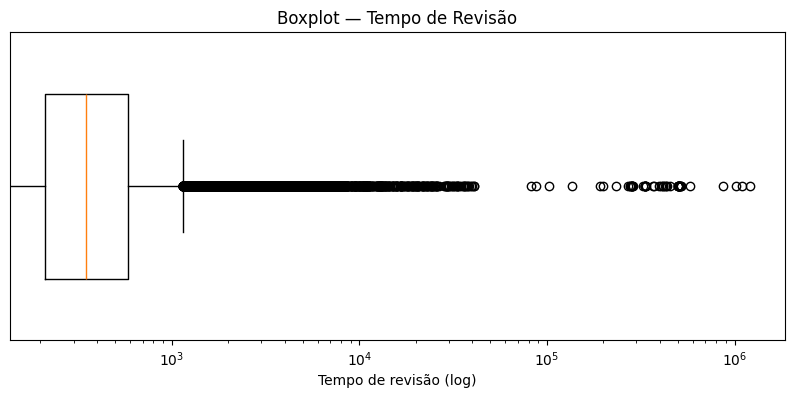

In [90]:
# Boxplot dos Tempos de Correção para analisar a dispersão dos dados e identificar outliers
plt.figure(figsize=(10, 4))
plt.boxplot(
    df_revisao["tempoCorrecao"],
    vert=False,
    widths=0.6
)

# Utilizar transformação logarítmica nos dados para melhor visualização do boxplot (diminui a escala da dispersão)
plt.xscale("log")
plt.yticks([])
plt.title("Boxplot — Tempo de Revisão")
plt.xlabel("Tempo de revisão (log)")
plt.show()

In [91]:
# Método para estabelecer limites inferior e superior, e posteriormente excluir outliers fora desse intervalo
q1 = df_revisao["tempoCorrecao"].quantile(0.25)
q3 = df_revisao["tempoCorrecao"].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

# Se o limite inferior for menor do que 0, alterá-lo para 0, pois não existe tempo negativo, então qualquer dado
# negativo é excluído, pois trata-se de erro de medição
if lim_inf < 0:
    lim_inf = 0

lim_inf, lim_sup

(0, np.float64(1149.5))

<Axes: >

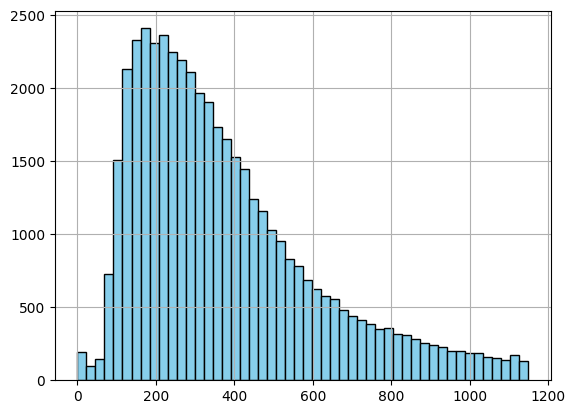

In [92]:
# Limpar outliers dos dados
df_revisao_limpo = df_revisao[
    (df_revisao["tempoCorrecao"] >= lim_inf) &
    (df_revisao["tempoCorrecao"] <= lim_sup)
]

# Armazenar outliers
df_revisao_outliers = df_revisao.loc[
    ~df_revisao.index.isin(df_revisao_limpo.index)
]

# Visualizar distribuição dos dados
df_revisao_limpo['tempoCorrecao'].hist(bins=50, color='skyblue', edgecolor='black')

<Axes: >

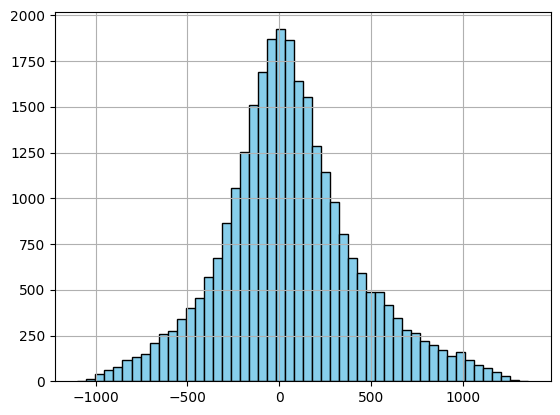

In [93]:
# Gráfico da distribuição das diferenças entre o tempo de correção e tempo de revisão, que é a métrica de interesse
diff_tempo = df_correcao_limpo["tempoCorrecao"] - df_revisao_limpo["tempoCorrecao"]
diff_tempo.hist(bins=50, color='skyblue', edgecolor='black')

In [94]:
# Contar o número de aparições dos corretores no dataframe de correções
contagem_correcao = df_correcao_limpo['nomeCorretor'].value_counts().reset_index()
contagem_correcao.columns = ['nomeCorretor', 'num_correcoes']
contagem_correcao

,nomeCorretor,num_correcoes
0,Letícia Loureiro de Nazareth,1027
1,Priscylla Santos Doria,1010
2,Ana Patrícia Rosinek,979
3,Gabriel de Paiva Pereira,913
4,Laíza Aparecida de Lima Mendonça,805
...,...,...
231,RITA A.,1
232,Ana Beatriz Nunes de Oliveira,1
233,MANOEL A.,1
234,Felipe da Costa Rico,1


In [95]:
# Contar o número de aparições dos corretores no dataframe de revisões
contagem_revisao = df_revisao_limpo['nomeCorretor'].value_counts().reset_index()
contagem_revisao.columns = ['nomeCorretor', 'num_revisoes']
contagem_revisao

,nomeCorretor,num_revisoes
0,Gabriel de Paiva Pereira,1151
1,Laíza Aparecida de Lima Mendonça,1114
2,Ana Karoline Abrantes Oliveira,1085
3,Ana Patrícia Rosinek,1073
4,Lucas Guimarães Oliveira,1051
...,...,...
218,Corretor CAROL A.,1
219,SUELI A.,1
220,Aline dos Santos Oliveira,1
221,Caroline Leticia Freitas,1


In [96]:
# Definindo o mínimo de amostras para o corretor ser considerado
limite_amostral = 10

# Identificar corretores que atendem a esse mínimo
corretores_ativos_corr = df_correcao_limpo['nomeCorretor'].value_counts()
corretores_ativos_corr = corretores_ativos_corr[corretores_ativos_corr > limite_amostral].index

corretores_ativos_rev = df_revisao_limpo['nomeCorretor'].value_counts()
corretores_ativos_rev = corretores_ativos_rev[corretores_ativos_rev > limite_amostral].index

# Filtrar os DataFrames originais
df_correcao_filtrado = df_correcao_limpo[df_correcao_limpo['nomeCorretor'].isin(corretores_ativos_corr)]
df_revisao_filtrado = df_revisao_limpo[df_revisao_limpo['nomeCorretor'].isin(corretores_ativos_rev)]

# Excluir linhas com dados faltantes
tempos_correcao = df_correcao_filtrado['tempoCorrecao'].dropna()
tempos_revisao = df_revisao_filtrado['tempoCorrecao'].dropna()

print('Número de Corretores:', len(corretores_ativos_corr))
print('Número de Revisores:', len(corretores_ativos_rev))
print('')
print('Total de redações com corretores que possuem amostra suficiente:', len(df_correcao_filtrado))
print('Total de redações com revisores que possuem amostra suficiente:', len(df_revisao_filtrado))

Número de Corretores: 176
Número de Revisores: 183

Total de redações com corretores que possuem amostra suficiente: 31342
Total de redações com revisores que possuem amostra suficiente: 44890


In [97]:
# Teste de hipótese paramétrico para duas amostras independentes
# Utiliza o teste t de Welch, que não assume igualdade de variâncias
# Hipóteses:
# H0: μ_correcao ≤ μ_revisao
# H1: μ_correcao > μ_revisao

from scipy.stats import ttest_ind

t_stat, p_valor = ttest_ind(
    tempos_correcao,
    tempos_revisao,
    equal_var=False,      # Teste t de Welch
    alternative='greater' # Teste unilateral
)

print(f"Estatística t (Welch): {t_stat:.4f}")
print(f"p-valor: {p_valor:.6f}")
print('')

alpha = 0.05

if p_valor < alpha:
    print(
        'Rejeita-se a hipótese nula ao nível de significância de 5%.'
    )
    print(
        'Há evidências estatísticas de que o tempo médio de correção '
        'é maior do que o tempo médio de revisão.'
    )
else:
    print(
        'Não se rejeita a hipótese nula ao nível de significância de 5%.'
    )
    print(
        'Não há evidências estatísticas suficientes de que o tempo médio '
        'de correção seja maior do que o tempo médio de revisão.'
    )

Estatística t (Welch): 25.8151
p-valor: 0.000000

Rejeita-se a hipótese nula ao nível de significância de 5%.
Há evidências estatísticas de que o tempo médio de correção é maior do que o tempo médio de revisão.


In [ ]:
# Teste não paramétrico de Mann–Whitney U para duas amostras independentes.
# Não assume normalidade das distribuições.
# Hipóteses (teste unilateral):
# H0: a distribuição dos tempos de correção é menor ou igual à dos tempos de revisão
# H1: os tempos de correção tendem a ser maiores que os tempos de revisão

from scipy.stats import mannwhitneyu

u_stat, p_valor_mw = mannwhitneyu(
    tempos_correcao,
    tempos_revisao,
    alternative='greater'
)

print(f"Estatística U: {u_stat:.0f}")
print(f"p-valor (Mann–Whitney U): {p_valor_mw:.6f}")
print("")

if p_valor_mw < 0.05:
    print(
        'Rejeita-se a hipótese nula ao nível de significância de 5%.'
    )
    print(
        "Há evidências estatísticas de que os tempos de correção tendem a ser maiores "
        "do que os tempos de revisão."
    )
else:
    print(
        'Não se rejeita a hipótese nula ao nível de significância de 5%.'
    )
    print(
        "Não há evidências estatísticas suficientes de que os tempos de correção "
        "sejam maiores do que os tempos de revisão."
    )


Estatística U: 758846336
p-valor (Mann–Whitney U): 0.000000

Rejeita-se a hipótese nula. 
Há evidência estatística de que os tempos de correção tendem a ser maiores do que os tempos de revisão.


In [99]:
import numpy as np
from scipy.stats import t

# Cálculo das médias dos tempos de correção e revisão
media_correcao = tempos_correcao.mean()
media_revisao = tempos_revisao.mean()

# Cálculo dos desvios padrão dos tempos de correção e revisão
std_correcao = tempos_correcao.std(ddof=1)
std_revisao = tempos_revisao.std(ddof=1)

# Cálculo do tamanho da amostra total dos tempos de correção e revisão
n_correcao = len(tempos_correcao)
n_revisao = len(tempos_revisao)

# Cálculo do ganho de tempo com a revisão
ganho_absoluto = media_correcao - media_revisao
ganho_percentual = ganho_absoluto / media_correcao * 100

print(f"Média Correção: {media_correcao:.2f} s")
print(f"Média Revisão: {media_revisao:.2f} s")
print(f"Ganho médio: {ganho_absoluto:.2f} s ({ganho_percentual:.2f}%)")

Média Correção: 426.59 s
Média Revisão: 376.13 s
Ganho médio: 50.46 s (11.83%)


In [102]:
# Erro padrão da diferença (Welch)
se_diff = np.sqrt(
    (std_correcao**2 / n_correcao) +
    (std_revisao**2 / n_revisao)
)

# Graus de liberdade (Welch–Satterthwaite)
df = (
    (std_correcao**2 / n_correcao + std_revisao**2 / n_revisao)**2
    /
    (
        ((std_correcao**2 / n_correcao)**2 / (n_correcao - 1)) +
        ((std_revisao**2 / n_revisao)**2 / (n_revisao - 1))
    )
)

# Valor crítico (95%)
alpha = 0.05
t_crit = t.ppf(1 - alpha/2, df)

# Intervalo de confiança
ic_inf = ganho_absoluto - t_crit * se_diff
ic_sup = ganho_absoluto + t_crit * se_diff

ic_inf_percentual = ic_inf / media_correcao * 100
ic_sup_percentual = ic_sup / media_correcao * 100

print(
    f"IC 95% do ganho médio: "
    f"[{ic_inf:.2f} s ; {ic_sup:.2f} s]"
)

print(
    f"IC 95% do ganho médio percentual: "
    f"[{ic_inf_percentual:.2f}% ; {ic_sup_percentual:.2f}%]"
)

IC 95% do ganho médio: [46.63 s ; 54.29 s]
IC 95% do ganho médio percentual: [10.93% ; 12.73%]


In [103]:
media_corr = df_correcao_filtrado.groupby('nomeCorretor')['tempoCorrecao'].mean()
media_rev = df_revisao_filtrado.groupby('nomeCorretor')['tempoCorrecao'].mean()

comparativo = pd.concat([media_corr, media_rev], axis=1, keys=['media_correcao', 'media_revisao'])
comparativo.to_csv('comparacao.csv')

comparativo_filtrado = comparativo.dropna()
comparativo_filtrado.to_csv('comparacao_10_amostras.csv')

comparativo_filtrado['diff_media'] = (
    comparativo_filtrado['media_correcao']
    - comparativo_filtrado['media_revisao']
)

/tmp/ipykernel_11641/816135088.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparativo_filtrado['diff_media'] = (


In [105]:
# Teste t de uma amostra (unilateral)
# H0: a média da diferença entre os tempos (diff_media) é igual a 0
# H1: a média da diferença entre os tempos (diff_media) é maior que 0
# Supõe-se que a distribuição da diferença média por corretor
# seja aproximadamente normal.

from scipy.stats import ttest_1samp

t_stat, p_valor = ttest_1samp(
    comparativo_filtrado['diff_media'],
    popmean=0,
    alternative='greater'
)

print(f"Estatística t: {t_stat:.4f}")
print(f"p-valor (teste t unilateral): {p_valor:.6f}")
print("")

if p_valor < 0.05:
    print(
        "Rejeita-se a hipótese nula ao nível de significância de 5%. "
    )
    print(
        "Há evidências estatísticas de que, em média, "
        "o tempo de correção é maior do que o tempo de revisão."
    )
else:
    print(
        "Não se rejeita a hipótese nula ao nível de significância de 5%. "
    )
    print(
        "Não há evidências estatísticas suficientes de que, em média, "
        "o tempo de correção seja maior do que o tempo de revisão."
    )



Estatística t: 10.6983
p-valor (teste t unilateral): 0.000000

Rejeita-se a hipótese nula ao nível de significância de 5%. 
Há evidências estatísticas de que, em média, o tempo de correção é maior do que o tempo de revisão.


In [108]:
# Teste de Wilcoxon para amostras pareadas (unilateral)
# H0: a mediana da diferença entre os tempos (diff_media) é igual a 0
# H1: a mediana da diferença entre os tempos (diff_media) é maior que 0
# Não assume normalidade da distribuição das diferenças.

from scipy.stats import wilcoxon

w_stat, p_valor_w = wilcoxon(
    comparativo_filtrado['diff_media'],
    alternative='greater'
)

print(f"Estatística W: {w_stat:.4f}")
print(f"p-valor (Wilcoxon unilateral): {p_valor_w:.6f}")
print("")

if p_valor_w < 0.05:
    print(
        "Rejeita-se a hipótese nula ao nível de significância de 5%. "
    )
    print(
        "Há evidências estatísticas de que a mediana da diferença "
        "entre correção e revisão é positiva."
    )
else:
    print(
        "Não se rejeita a hipótese nula ao nível de significância de 5%. "
    )
    print(
        "Não há evidências estatísticas suficientes de que a mediana "
        "da diferença seja positiva."
    )

Estatística W: 9865.0000
p-valor (Wilcoxon unilateral): 0.000000

Rejeita-se a hipótese nula ao nível de significância de 5%. 
Há evidências estatísticas de que a mediana da diferença entre correção e revisão é positiva.


In [109]:
print("Estatísticas descritivas das diferenças entre correção e revisão")
comparativo_filtrado['diff_media'].describe()

Estatísticas descritivas das diferenças entre correção e revisão


count    146.0
mean      89.3
std      100.8
min     -130.7
25%       18.5
50%       65.4
75%      146.1
max      497.6
Name: diff_media, dtype: float64

In [110]:
percentual_melhora = (
    (comparativo_filtrado['diff_media'] > 0).mean() * 100
)

print(f"{percentual_melhora:.1f}% dos corretores tiveram redução no tempo médio.")

81.5% dos corretores tiveram redução no tempo médio.


In [111]:
# Criar um dataframe com as médias, desvio padrão e amostra por corretor das redações corrigidas
stats_correcao = (
    df_correcao_filtrado
    .groupby('nomeCorretor')['tempoCorrecao']
    .agg(
        media_correcao='mean',
        std_correcao='std',
        n_correcao='count'
    )
)

# Criar um dataframe com as médias, desvio padrão e amostra por corretor das redações revisadas
stats_revisao = (
    df_revisao_filtrado
    .groupby('nomeCorretor')['tempoCorrecao']
    .agg(
        media_revisao='mean',
        std_revisao='std',
        n_revisao='count'
    )
)

# Agregar correções e revisões por corretor
comparativo_filtrado = (
    stats_correcao
    .join(stats_revisao, how='inner')
)

# Calcular a diferença das duas médias por corretor
comparativo_filtrado['diff_media'] = (
    comparativo_filtrado['media_correcao']
    - comparativo_filtrado['media_revisao']
)

# Calcular o percentual dessas diferenças
comparativo_filtrado['percentual'] = (
    comparativo_filtrado['diff_media']
    / comparativo_filtrado['media_correcao']
)

# Formatar para percentual
comparativo_filtrado['percentual'] = (
    (comparativo_filtrado['percentual'] * 100).round(1).astype(str) + '%'
)

In [112]:
import numpy as np
from scipy.stats import norm

# Definir z de acordo com o intervalo de confiança de tamanho 95%. Numa curva Normal, 
# funcionaria como a parte "dentro" do intervalo 2.5% - 97.5%.
z = norm.ppf(0.975)

# Cálculo do erro padrão, que é a base para o cálculo dos limites inferior e superior
comparativo_filtrado['se_diff'] = np.sqrt(
    (comparativo_filtrado['std_correcao']**2 / comparativo_filtrado['n_correcao']) +
    (comparativo_filtrado['std_revisao']**2 / comparativo_filtrado['n_revisao'])
)

# Cálculo do limite inferior
comparativo_filtrado['diff_ic_inf'] = (
    comparativo_filtrado['diff_media'] - z * comparativo_filtrado['se_diff']
)

# Cálculo do limite superior
comparativo_filtrado['diff_ic_sup'] = (
    comparativo_filtrado['diff_media'] + z * comparativo_filtrado['se_diff']
)

# Cálculo percentual do limite inferior
comparativo_filtrado['perc_ic_inf'] = (
    comparativo_filtrado['diff_ic_inf']
    / comparativo_filtrado['media_correcao']
) * 100

# Cálculo percentual do limite superior
comparativo_filtrado['perc_ic_sup'] = (
    comparativo_filtrado['diff_ic_sup']
    / comparativo_filtrado['media_correcao']
) * 100

# Cálculo do Intervalo de Confiança
comparativo_filtrado['Intervalo de Confiança'] = (
    comparativo_filtrado['perc_ic_inf'].round(1).astype(str) +
    '% – ' +
    comparativo_filtrado['perc_ic_sup'].round(1).astype(str) +
    '%'
)

#comparativo_filtrado.to_csv('resultados.csv')

In [ ]:
# Filtrar colunas mais relevantes dos resultados
resultados_filtrados = comparativo_filtrado[
    [
        'media_correcao',
        'n_correcao',
        'media_revisao',
        'n_revisao',
        'diff_media',
        'percentual',
        'Intervalo de Confiança'
    ]
]
#resultados_filtrados.to_csv('resultados_filtrados.csv')
resultados_filtrados

,media_correcao,n_correcao,media_revisao,n_revisao,diff_media,percentual,Intervalo de Confiança
nomeCorretor,,,,,,,
Ademir Giraldello,533.8,19,503.8,452,30.0,5.6%,-15.3% – 26.6%
Adriana Gecivania Torres Silva,292.4,76,300.6,189,-8.2,-2.8%,-21.0% – 15.4%
Adriele Coutinho de Oliveira,464.5,15,478.4,34,-13.9,-3.0%,-24.2% – 18.2%
Alex Figueiredo,450.2,119,412.1,19,38.2,8.5%,-15.9% – 32.8%
Amanda Lopes dos Santos,347.3,39,366.3,161,-19.1,-5.5%,-27.5% – 16.5%
...,...,...,...,...,...,...,...
Viviane Júnia da Silva Gomes,774.8,15,614.7,81,160.1,20.7%,-6.0% – 47.4%
Wagner Teixeira de Andrade,526.5,92,521.2,236,5.3,1.0%,-6.3% – 8.3%
Waleska Valentim,716.1,19,368.6,81,347.4,48.5%,31.1% – 65.9%
